## Problem Statement: Image Classification on CIFAR-10 Dataset using Convolutional Neural Networks

### Importing Libraries:

In [1]:
pip install tensorflow numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [1]:
import sys 
!{sys.executable} -m pip install nltk

### Load and Preprocess the Data
- For this example, we will use the CIFAR-10 dataset, which is a collection of 60,000 32x32 color images in 10 classes.

In [3]:
# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values to be between 0 and 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


### Define the CNN Model
- Create the CNN model using Keras’ Sequential API.

In [4]:
model = models.Sequential()

# First convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten the output and feed it into a dense layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


C:\Users\Priya\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile the Model
- Compiling the model with an optimizer, loss function, and metrics to monitor.

In [6]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Train the Model
- Training the model using the training data.

In [7]:
history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.3438 - loss: 1.7610 - val_accuracy: 0.5294 - val_loss: 1.3105
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.5667 - loss: 1.2236 - val_accuracy: 0.6172 - val_loss: 1.0861
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6242 - loss: 1.0568 - val_accuracy: 0.6474 - val_loss: 0.9953
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6648 - loss: 0.9460 - val_accuracy: 0.6745 - val_loss: 0.9410
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6898 - loss: 0.8795 - val_accuracy: 0.6768 - val_loss: 0.9253
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7147 - loss: 0.8148 - val_accuracy: 0.6805 - val_loss: 0.9151
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7359 - loss: 0.7545 - val_accuracy: 0.6892 - val_loss: 0.8929
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7492 -

###  Evaluate the Model
- Evaluating the model’s performance on the test data.

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")


313/313 - 3s - 9ms/step - accuracy: 0.7269 - loss: 0.8558
Test accuracy: 0.7268999814987183


### Visualize Training Results
- Plot the training and validation accuracy and loss.

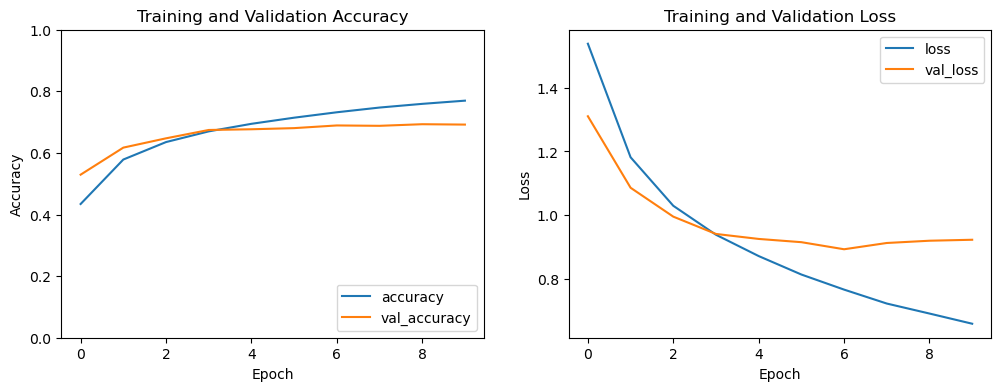

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


### Make Predictions
 - Using the model to make predictions on new images.

In [9]:
predictions = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


### Save the Model
- Save the trained model to a file.

In [13]:
model.save('cifar10_cnn_model.h5')


### Load and Use the Saved Model
- We can load and use the saved model later for predictions.

In [11]:
loaded_model = tf.keras.models.load_model('cifar10_cnn_model.h5')
loaded_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6971 - loss: 0.9005


[0.9227629899978638, 0.6919999718666077]

## Performance of the Model:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


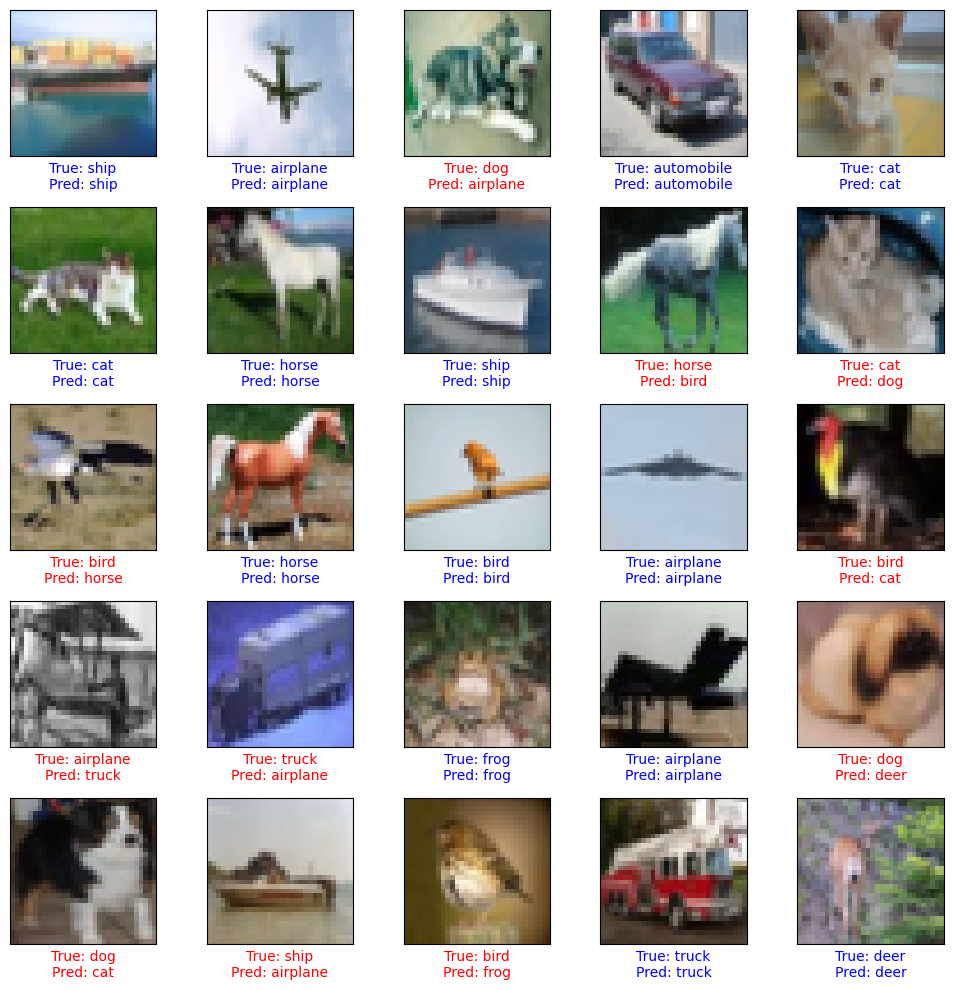

In [12]:
# Class names in CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Function to plot images along with true and predicted labels
def plot_images(images, true_labels, predicted_labels, class_names):
    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        true_label = class_names[np.argmax(true_labels[i])]
        predicted_label = class_names[np.argmax(predicted_labels[i])]
        color = 'blue' if true_label == predicted_label else 'red'
        plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.tight_layout()
    plt.show()

# Let's Select 25 random images from the test set
indices = np.random.choice(X_test.shape[0], 25, replace=False)
test_images = X_test[indices]
test_labels = y_test[indices]

# Make predictions on these images
predictions = loaded_model.predict(test_images)

# Plot the images along with true and predicted labels
plot_images(test_images, test_labels, predictions, class_names)